# Deriving a correct velocity scaling thermostat

This notebook is a guided example of how you can tackle a technically hard derivation in a controlled way. It is background information, just to give you an impression on how statitical mechanics, math, and AI can be used to derive a simulation method, in this case the so-called Bussi thermostat. 

The steps are:
- Start from a *clear physical/computational goal*.
- Choose a *mathematical object* that matches that goal (here: a Laplace transform).
- Reduce the hard problem to a sequence of **standard steps** (here: Gaussian integrals).
- Recognize the resulting expression as a **known distribution** (here: noncentral $\chi^2$).
- Implement the result with a reliable numerical library (SciPy).
  
> The mathematics below is beyond what you are expected to reproduce in a bachelor course.  
> But the *approach* (what to compute, why that object helps, what to recognize) is something you can learn and reuse.  
>  
> Also: This derivation was worked out with the help of ChatGPT. The point is not “AI did magic”, but that
> you can get meaningful results if you (i) understand the goal deeply, (ii) choose the right mathematical route,
> and (iii) ask the model to do specific well-posed steps you can check.

---

## What are we trying to achieve?

In an NVT Busi-thermostat step, we rescale all velocities by a factor $\alpha$:
$$
\mathbf v_i \leftarrow \alpha\,\mathbf v_i.
$$

Differently from the Berendsen thermostat, the scale factor $\alpha$ will be sampled from a probability distribution.
A principled way to choose $\alpha$ is to first generate a new kinetic energy $K'$ with the correct conditional probability law, and then set
$$
\alpha = \sqrt{K'/K}.
$$

So the core mathematical problem is:
> Given the current kinetic energy $K$, sample a new $K'$ such that the thermostat has the canonical kinetic-energy
> distribution in equilibrium, while changing $K$ only gradually (controlled by a parameter $c$).

We first derive the exact conditional distribution $p(K' \mid K)$, i.e., the probability for generating a value $K'$ from a given value $K$.


## 1. Start with a simple (but powerful) model update for velocities

We work in mass-scaled, temperature-scaled velocity components so that at equilibrium each component has variance 1. At the end we will transform back to physical units.

Consider one velocity component evolving according to a Ornstein-Uhlenbeck process:
$$
v' = c\,v + \sqrt{1-c^2}\,g,
$$
where $g \sim \mathcal N(0,1)$, i.e. a scaledally distributed variable with mean 0 and variance 1, and $0\le c \le 1$.

Interpretation:
- It is well known that the sum of 2, independent, scaledally distributed variables is normal.
- $c$ controls memory of the previous velocity.
- $\sqrt{1-c^2}$ controls how much fresh thermal noise we add.
- The variance of the updated velocity is: $\langle v'^2\rangle = c^2 \, \langle v^2 \rangle  + (1-c^2)$.
- The stationary value is a normally distributed variable with $\langle v'^2\rangle  = \langle v^2 \rangle  = 1$.  
- If $c=0$: completely refresh the velocity from a Gaussian.
- If $c\to 1$: almost no change.

Now take $f$ independent components (all degrees of freedom):
$$
K = \sum_{i=1}^{f} v_i^2,\qquad K' = \sum_{i=1}^{f} (v_i')^2.
$$

We want the conditional distribution of $K'$ given the current value $K$.


## 2. Why a Laplace transform?

Directly finding the probability density function (pdf) of $K'$ is messy because $K'$ is a sum of squares of Gaussians.

A standard trick is to compute the Laplace transform (or generating function):
$$
\phi(s) = \left \langle e^{-sK'}\right\rangle = \int_0^\infty p(K'|K) e^{-sK'} dK'.
$$

Why is this useful?

- Exponentials turn sums into products:
  $$e^{-s\sum_i x_i}=\prod_i e^{-s x_i}.$$
- Gaussian integrals of the form $\int e^{-a g^2 - b g}\,dg$ are standard (complete the square).
- Once $\phi(s)$ is simplified, we can often recognize it as the Laplace transform of a known distribution.

So our plan is:

1) Write $\phi(s)$ as a product of 1D Gaussian integrals.  
2) Do the Gaussian integral once, then raise to power $f$.  
3) Recognize the final $\phi(s)$, as a Laplace transform of a known function.
4) Use the function corresponding to the inverse transform of $\phi(s)$ to generate values $K'$.

That’s the entire strategy.

When we have the analytical expression of $\phi(s)$ we hope that the inverse Laplace transform is known, and get an expression for $p(K')$ and an algorithm to draw from it. With this distribution, we can generate new values $K'$, that provide the scaling parameter $\alpha$.

## 3. Compute the Laplace transform

The  $\langle e^{-sK'}\rangle$ follows from avering over the normally distributed variables $g_i$.
$$
 K' = \sum_{i=1}^{f} (v_i')^2 = \sum_{i=1}^{f} \left( c\, v_i + \sqrt{1-c^2} \,g_i \right )^2
$$
Using the proporty of the exponentials turn sums into products, and the fact that the random variables $g_i$ are independent, gives:
$$
\left\langle e^{-sK'}\right \rangle = \prod_{i=0}^f \left\langle e^{-s (c\, v_i + \sqrt{1-c^2} \,g_i)^2 }\right \rangle
$$

Define $a=\sqrt{1-c^2}$. For one component, averaging using the normal distribution with mean $0$ and variance $1$ results in the integral:

$$
I(s;v) = \left\langle \exp\left(-s(c v + a g)^2\right)\right \rangle
= \int_{-\infty}^{\infty}\frac{dg}{\sqrt{2\pi}}
\exp\left(-\frac{g^2}{2}-s(c v + a g)^2\right).
$$

We do this integral by completing the square. Then for $f$ components:

$$
\phi(s)=\prod_{i=1}^{f} I(s;v_i).
$$

$$
\begin{align*}
I(s;v) &= \int_{-\infty}^{\infty}\frac{dg}{\sqrt{2\pi}}
\exp\left(-\frac{g^2}{2}-s(c v + a g)^2\right),\\
&=\int_{-\infty}^{\infty}\frac{dg}{\sqrt{2\pi}}
\exp\left(-\frac{1}{2} \left(1 + 2 s a^2\right) g^2 - 2 \, (s c v a) \, g - s c^2 v^2\right)\\
&= \exp\left(-  s c^2 v^2 + \frac{2 (s \, c \,v \,a)^2}{1 + 2 s a^2} \right) \int_{-\infty}^{\infty}\frac{dg}{\sqrt{2\pi}}
\, \exp\left(-\frac{1}{2} \left(1 + 2 s a^2\right) \left ( g + \frac{2 s c v a}{1 + 2 s a^2} \right )^2 \right)\\
&= \frac{1}{\sqrt{1 + 2 s a^2}} \, \exp\left(- \frac{s c^2 v^2}{1 + 2 s a^2} \right) 
\end{align*}
$$

Because $\sum_i v_i^2 = K$, the product simplifies to a function of $K$ only:
$$
\boxed{
\phi(s) = (\sqrt{1 + 2 s a^2})^{-\frac{f}{2}} \, \exp\left(- \frac{s c^2 \sum_i v_i^2}{1 + 2 s a^2} \right) = (1 + 2 s a^2)^{-\frac{f}{2}} \exp\left(- \frac{s c^2 K}{1 + 2 s a^2} \right)
}
$$

If math gets complex you might attempt to use a symbolic math package to find the expression. It is anyways a good idea to check your math:

In [1]:
import sympy as sp # symbolic mathematics, to install it do: 'pip install sympy'

# Symbols
s, a, c, v = sp.symbols('s a c v', positive=True, real=True)
g = sp.symbols('g', real=True)

# 1D integral: I(s;v) = E[ exp(-s (c v + a g)^2) ] with g~N(0,1)
integrand = sp.exp(-g**2/2 - s*(c*v + a*g)**2) / sp.sqrt(2*sp.pi)
I = sp.integrate(integrand, (g, -sp.oo, sp.oo), meijerg=True).doit(conds='none')
I_simplified = sp.simplify(I)
def simplify_exp_rational(e):
    e2 = e.replace(lambda t: t.func is sp.exp,
                   lambda t: sp.exp(sp.ratsimp(t.args[0])))
    return sp.simplify(sp.radsimp(sp.powsimp(e2, force=True)))
I_simplified = simplify_exp_rational(I_simplified)
I_simplified

exp(-c**2*s*v**2/(2*a**2*s + 1))/sqrt(2*a**2*s + 1)

Therefore for $f$ DOF and $K=\sum_i v_i^2$:

$$
\boxed{
\phi(s)= \left \langle e^{-sK'} \right \rangle_K
=
(1+2 s a^2)^{-f/2}\exp\left(-\frac{s c^2 K}{1+2 s a^2}\right)
}
$$


## 4. Recognize the distribution

Here is some mathematically knowledge, I did not know, but ChatGPT 5.2, did:

If $X \sim \chi^2_{\nu}(\lambda)$ (noncentral chi-square), then:

$$
\langle  e^{-tX} \rangle
=
(1+2t)^{-\nu/2}\exp\left(-\frac{\lambda t}{1+2t}\right).
$$

We can match our $\phi(s)$ by choosing:
- $t = s a^2$,
- $\nu = f$,
- $\lambda = \dfrac{c^2}{a^2}K$.

Then $K' = a^2 X$, so:

$$
\boxed{
K' =\; a^2\,X,\qquad
X \sim \chi^2_f\!\left(\lambda\right),\qquad
\lambda=\frac{c^2}{a^2}K,\qquad a^2=1-c^2.
}
$$


## 5. Sampling $K'$ in practice with SciPy

SciPy can sample the noncentral chi-square distribution exactly:

- `scipy.stats.ncx2(df, nc)` for $\chi^2_{\text{df}}(\text{nc})$.

Algorithm (normalized units):
1. $a^2 = 1-c^2$
2. $\lambda = (c^2/a^2)K$
3. sample $X \sim \text{ncx2}(f,\lambda)$
4. $K' = a^2 X$
5. $\alpha=\sqrt{K'/K}$, rescale velocities.


In [2]:
import numpy as np
from scipy.stats import ncx2 # install with 'pip install scipy'

def sample_bussi_kinetic_energy(K_norm, f, c, rng=None):
    """
    Sample new normalized kinetic energy for Bussi thermostat.
    
    This implements the sampling from the conditional distribution:
        P(K' | K) for the Bussi thermostat
    
    The distribution is constructed to satisfy detailed balance for the
    canonical ensemble while providing smooth temperature dynamics.
    
    Parameters
    ----------
    K_norm : float
        Current normalized kinetic energy = sum(m*v^2) / (kB*T)
    f : int
        Degrees of freedom
    c : float
        Coupling parameter = exp(-dt/tau)
    rng : np.random.Generator, optional
        Random number generator for reproducibility (default: None)
    
    Returns
    -------
    K_norm_new : float
        New normalized kinetic energy sampled from conditional distribution
    
    """
    if rng is None:
        rng = np.random.default_rng()

    a2 = 1.0 - c**2
    if a2 <= 0.0:
        return float(K_norm)  # No rescaling if c=1 (tau->inf)

    lam = (c**2 / a2) * K_norm
    X = ncx2.rvs(df=f, nc=lam, random_state=rng)
    K_norm_new = a2 * X
    return K_norm_new

## 6. Mapping to MD units (LJ reduced units)

In a real MD code you compute:

$$
K = \sum_{i=1}^N \frac{m_i v_i^2}{2}.
$$

Define the dimensionless variable:

$$
K_\mathrm{norm} = \frac{2K}{k_B T} = \frac{1}{k_B T} \sum_{i=1}^N m_i v_i^2.
$$

Then apply the normalized sampler to $K_\mathrm{norm}$ and map back:

$$
K' = \frac{1}{2}k_B T\, K'_\mathrm{norm}.
$$


In [7]:
def bussi_thermostat(velocities, masses, temperature, nu, dt, kB=1.0, 
                     remove_com=True, rng=None):
    """
    Bussi-Donadio-Parrinello thermostat (Canonical Sampling Velocity Rescaling).
    
    The Bussi thermostat (also known as CSVR) combines the smooth temperature
    control of Berendsen with stochastic sampling to produce the correct
    canonical ensemble. It's one of the best thermostats for production runs.
    
    Algorithm:
    1. Calculate current normalized kinetic energy K = sum(m * v^2) / (kB * T)
    2. Sample new normalized kinetic energy K' from the correct conditional distribution
    3. Rescale all velocities by alpha = sqrt(K'/K)
    
    The key insight is that K' is sampled from a non-central chi-squared
    distribution that depends on K, the target temperature, and the coupling
    strength (determined by tau).
    
    Parameters
    ----------
    velocities : ndarray
        Current velocity array, shape (N, dim)
    masses : ndarray or float
        Mass of each particle
    temperature : float
        Target temperature
    nu : float
        Collision frequency for the thermostat. Determines the strength of coupling to the heat bath.
    dt : float
        Timestep size
    kB : float, optional
        Boltzmann constant (default: 1.0)
    remove_com : bool, optional
        If True, remove COM motion when computing kinetic energy (default: True)
    rng : np.random.Generator, optional
        Random number generator for reproducibility
    
    Returns
    -------
    velocities_new : ndarray
        Rescaled velocity array, shape (N, dim)
    
    Notes
    -----
    Properties:
    - Generates correct canonical ensemble (exact NVT)
    - Smooth temperature control (like Berendsen)
    - Minimal perturbation to dynamics
    - Preserves momentum conservation (if remove_com=True)
    - Best choice for production MD runs
    
    TASK FOR STUDENTS:
    - Compute current kinetic energy in "normalized" units (K_norm = 2*K/(f*kB*T))
    - Calculate the coupling parameter c = exp(-nu*dt)
    - Sample new K' from the conditional distribution
    - Rescale velocities appropriately
    """
    if rng is None:
        rng = np.random.default_rng()
    
    # Copy velocities
    v_work = np.array(velocities, copy=True)
    N, dim = v_work.shape
    
    # Convert masses to array with shape (N, 1) for broadcasting
    masses = np.asarray(masses).reshape(-1, 1)
    
    # Degrees of freedom
    f = N * dim
    if remove_com:
        # Remove COM velocity before computing kinetic energy
        total_mass = np.sum(masses)
        v_com = np.sum(masses * v_work, axis=0) / total_mass
        v_work = v_work - v_com
        f = f - dim  # Lose dim degrees of freedom for COM constraint
    
    # Calculate current kinetic energy in normalized units
    # K_normalized = K / (0.5 * f * kB * T) = sum(m*v^2) / (kB * T)
    K_norm = np.sum(masses * v_work**2) / (kB * temperature)
    
    
    # Calculate coupling parameter
    # c = exp(-nu*dt) determines the strength of coupling to heat bath
    # c → 1: weak coupling (small nu)
    # c → 0: strong coupling (large nu)
    c = np.exp(-nu * dt)
    
    # Sample new kinetic energy from the conditional distribution
    # This is the heart of the Bussi algorithm
    K_norm_new = sample_bussi_kinetic_energy(K_norm, f, c, rng=rng)
    
    # Calculate rescaling factor
    alpha = np.sqrt(K_norm_new / K_norm)
    
    # Rescale velocities
    v_work = alpha * v_work
    
    # Add back COM velocity if it was removed
    if remove_com:
        v_work = v_work + v_com
    
    return v_work

## 7. Verification

**Tests**:

1. For a choosen, not too large value of the number of degrees of freedom $f$, sample velocities from the normalized Maxwell-Boltzmann distribution (i.e. $\mathcal{N}(0,1)$), compute values $K$ and make a histogram.
2. Generate a series of $K'$ values using ``sample_Kprime_conditional_normalized``, create the histogram and compare with the one created from sampling the velocity distribution. Do this first for $c=0$ and then for intermediate values.
3. Sample velocities from the Maxwell-Boltzmann distribution for a small $f$. Rescale these velocities using ``bussi_thermostat``. Check if the rescaled velocities still obey the Maxwell-Boltzmann distribution.

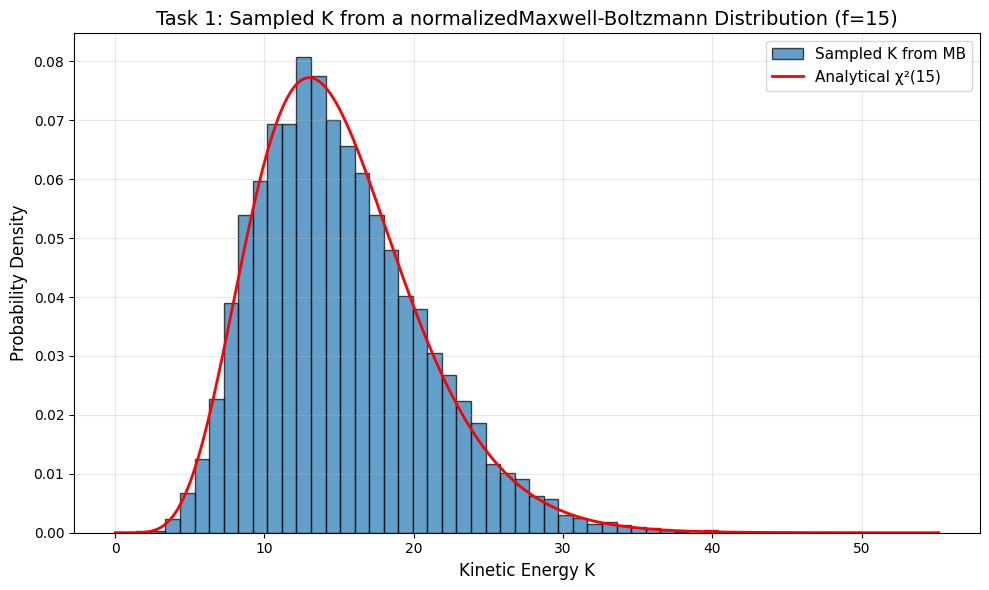

Mean K (sampled): 15.1240
Mean K (analytical): 15.0000
Std K (sampled): 5.5611
Std K (analytical): 5.4772


In [8]:
# Test 1: Sample velocities from Maxwell-Boltzmann and create histogram of K
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Parameters
f = 15  # degrees of freedom (e.g., 5 particles in 3D)
n_samples = 10000  # number of samples

# Sample from Maxwell-Boltzmann distribution
# In normalized units, each velocity component is N(0, 1)
rng = np.random.default_rng(42)
velocities = rng.normal(0, 1, size=(n_samples, f))

# Compute K = sum(v_i^2) for each sample (in physical units)
K_samples = np.sum(velocities**2, axis=1)

# Create histogram
fig, ax = plt.subplots(figsize=(10, 6))
counts, bins, patches = ax.hist(K_samples, bins=50, density=True, alpha=0.7, 
                                  label='Sampled K from MB', edgecolor='black')

K_analytical = np.linspace(0, K_samples.max() * 1.1, 1000)
pdf_X = chi2.pdf(K_analytical, df=f)
pdf_K = pdf_X  # chain rule for transformation
ax.plot(K_analytical, pdf_K, 'r-', linewidth=2, label=f'Analytical χ²({f})')

ax.set_xlabel('Kinetic Energy K', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title(f'Task 1: Sampled K from a normalizedMaxwell-Boltzmann Distribution (f={f})', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean K (sampled): {np.mean(K_samples):.4f}")
print(f"Mean K (analytical): {f:.4f}")
print(f"Std K (sampled): {np.std(K_samples):.4f}")
print(f"Std K (analytical): {np.sqrt(2 * f):.4f}")



c=0.0:
    Mean K' (sampled): 14.9814
    Mean K (direct MB): 15.1240
    Mean K (analytical): 15.0000

c=0.6:
    Mean K' (sampled): 15.0333
    Mean K (direct MB): 15.1240
    Mean K (analytical): 15.0000


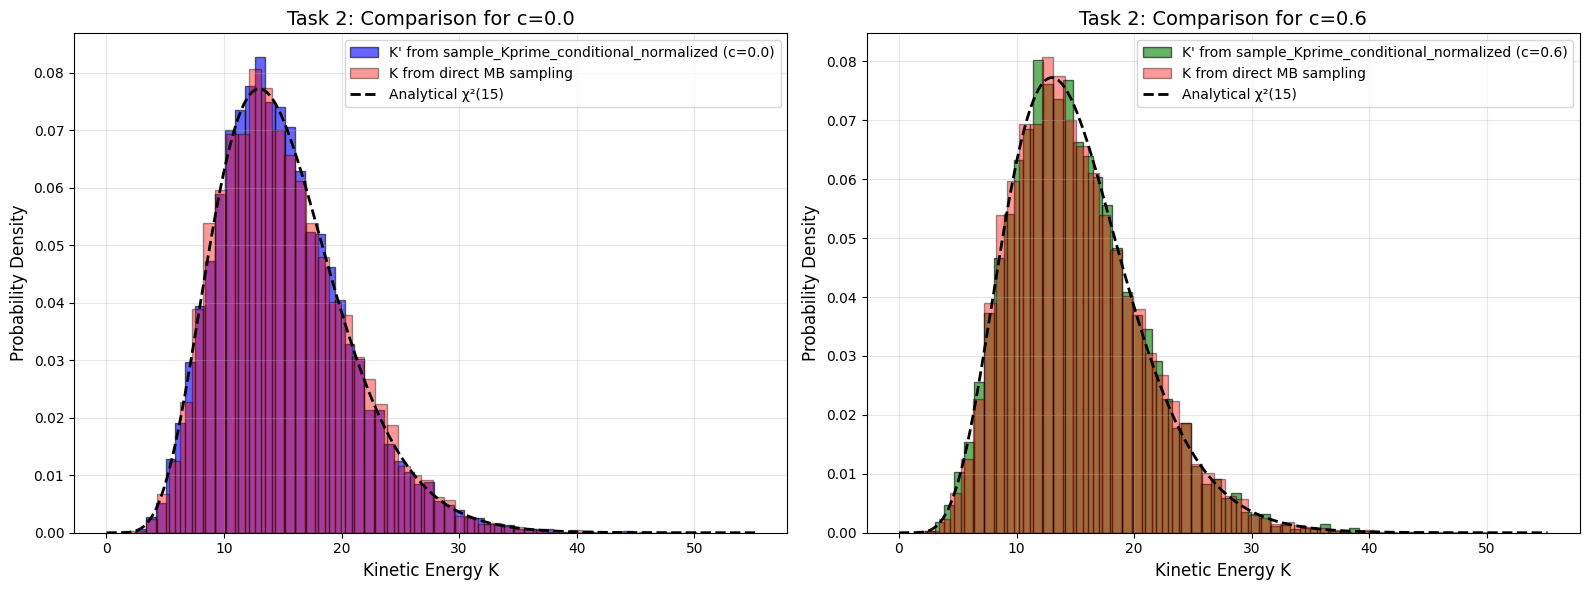


Note: For c=0, K' should match the equilibrium distribution (same as direct MB sampling).
For c=0.95, K' is more correlated with the initial K but still converges to equilibrium.


In [11]:
# Test 2: Generate K' using sample_Kprime_physical and compare with MB distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# For each K from equilibrium distribution, generate K' conditioned on that K
# This correctly represents the CSVR thermostat's equilibrium behavior
c_values = [0.0, 0.6]
colors = ['blue', 'green']

for idx, (c_val, color) in enumerate(zip(c_values, colors)):
    ax = axes[idx]
    
    # Generate K' values using sample_Kprime_physical
    # IMPORTANT: Each K' is conditioned on a different K from the equilibrium distribution
    Kprime_samples = np.array([
        sample_bussi_kinetic_energy(K, f, c_val, rng=rng)
        for K in K_samples
    ])
    
    # Plot histogram of K' samples
    ax.hist(Kprime_samples, bins=50, density=True, alpha=0.6, 
            label=f"K' from sample_Kprime_conditional_normalized (c={c_val})", 
            color=color, edgecolor='black')
    
    # For comparison, also plot K from direct MB sampling
    ax.hist(K_samples, bins=50, density=True, alpha=0.4, 
            label='K from direct MB sampling', color='red', edgecolor='black')
    
    # Overlay analytical curve
    K_analytical = np.linspace(0, max(Kprime_samples.max(), K_samples.max()) * 1.1, 1000)
    pdf_K = chi2.pdf(K_analytical, df=f)
    ax.plot(K_analytical, pdf_K, 'k--', linewidth=2, label=f'Analytical χ²({f})')
    
    ax.set_xlabel('Kinetic Energy K', fontsize=12)
    ax.set_ylabel('Probability Density', fontsize=12)
    ax.set_title(f'Task 2: Comparison for c={c_val}', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    print(f"\nc={c_val}:")
    print(f"    Mean K' (sampled): {np.mean(Kprime_samples):.4f}")
    print(f"    Mean K (direct MB): {np.mean(K_samples):.4f}")
    print(f"    Mean K (analytical): {f:.4f}")

plt.tight_layout()
plt.show()

print("\nNote: For c=0, K' should match the equilibrium distribution (same as direct MB sampling).")
print("For c=0.95, K' is more correlated with the initial K but still converges to equilibrium.")


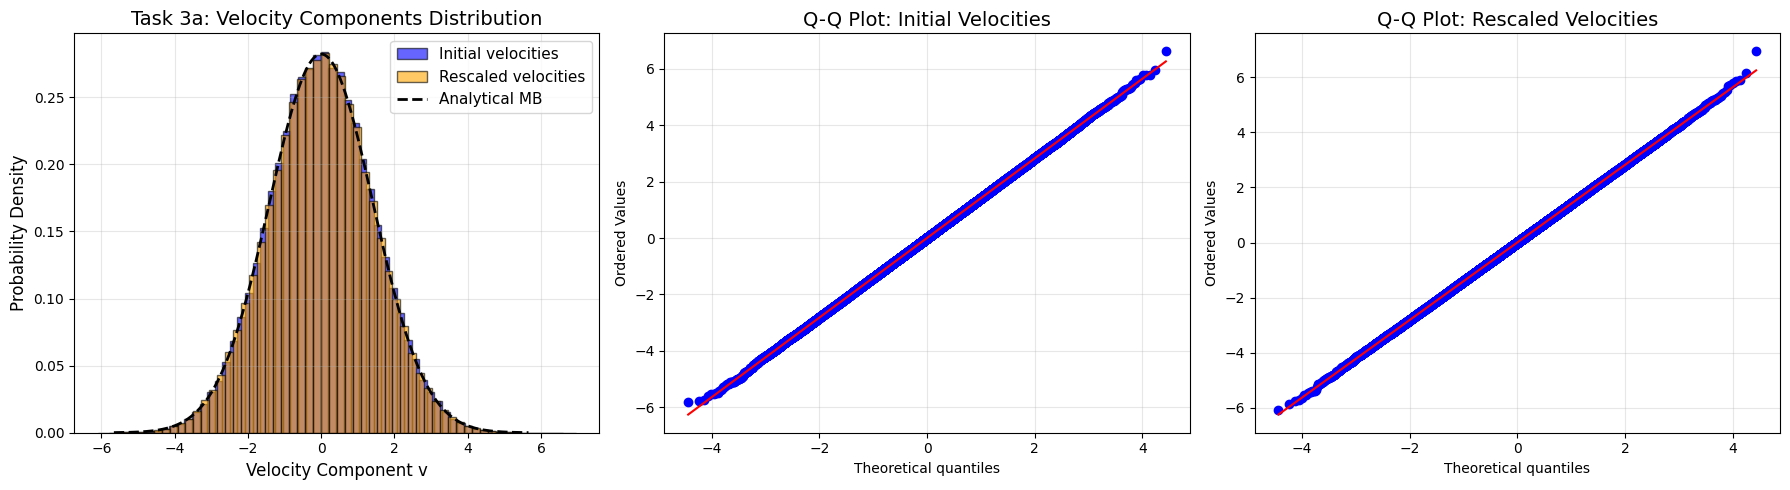

Statistical Analysis:
Initial velocities:
  Mean: 0.001636 (expected: 0.0)
  Std:  1.410722 (expected: 1.414214)

Rescaled velocities:
  Mean: 0.001636 (expected: 0.0)
  Std:  1.410470 (expected: 1.414214)

Kolmogorov-Smirnov Test (H0: data follows MB distribution):
  Initial:  statistic=0.001772, p-value=0.7332
  Rescaled: statistic=0.001946, p-value=0.6205
  (p > 0.05 means we cannot reject H0, i.e., data is consistent with MB)


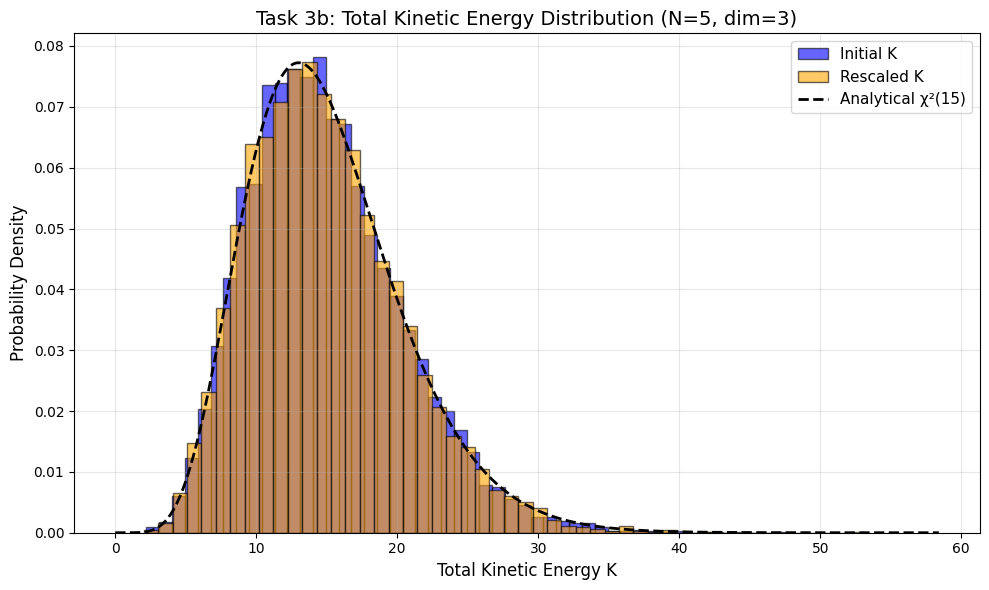


Kinetic Energy Statistics:
  Initial K:  mean=14.9261, std=5.4404
  Rescaled K: mean=14.9207, std=5.4310
  Analytical: mean=15.0000, std=5.4772


In [10]:
# Test 3: Verify that the Bussi thermostat preserves Maxwell-Boltzmann distribution
from scipy import stats

# Parameters for Bussi thermostat
kB = 1.0  # Boltzmann constant in simulation units
T = 2.0  # target temperature
dt = 0.01  # timestep
nu = 10.0  # thermostat collision frequency
N_particles = 5  # number of particles
dim = 3  # 3D
n_samples = 10000

# Sample velocities from Maxwell-Boltzmann for a small f
# Shape: (n_samples, N_particles, dim)
masses = np.ones(N_particles)  # all particles have mass 1
velocities_initial = rng.normal(0, np.sqrt(kB * T), size=(n_samples, N_particles, dim))

# Apply Bussi thermostat to each sample
velocities_rescaled = np.array([
    bussi_thermostat(v, masses, T, nu, dt, kB=kB, remove_com=True, rng=rng)
    for v in velocities_initial
])

# Flatten the velocity components for statistical analysis
v_initial_flat = velocities_initial.reshape(-1)
v_rescaled_flat = velocities_rescaled.reshape(-1)

# Create comparison plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Histogram of individual velocity components
ax = axes[0]
ax.hist(v_initial_flat, bins=60, density=True, alpha=0.6, 
        label='Initial velocities', color='blue', edgecolor='black')
ax.hist(v_rescaled_flat, bins=60, density=True, alpha=0.6, 
        label='Rescaled velocities', color='orange', edgecolor='black')

# Overlay analytical MB distribution for velocity components
v_range = np.linspace(-4*np.sqrt(kB*T), 4*np.sqrt(kB*T), 1000)
mb_pdf = stats.norm.pdf(v_range, 0, np.sqrt(kB * T))
ax.plot(v_range, mb_pdf, 'k--', linewidth=2, label='Analytical MB')

ax.set_xlabel('Velocity Component v', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Task 3a: Velocity Components Distribution', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 2: Q-Q plot to check normality
ax = axes[1]
stats.probplot(v_initial_flat, dist="norm", plot=ax)
ax.set_title('Q-Q Plot: Initial Velocities', fontsize=14)
ax.grid(True, alpha=0.3)

ax = axes[2]
stats.probplot(v_rescaled_flat, dist="norm", plot=ax)
ax.set_title('Q-Q Plot: Rescaled Velocities', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical tests
print("Statistical Analysis:")
print("=" * 60)
print(f"Initial velocities:")
print(f"  Mean: {np.mean(v_initial_flat):.6f} (expected: 0.0)")
print(f"  Std:  {np.std(v_initial_flat):.6f} (expected: {np.sqrt(kB * T):.6f})")

print(f"\nRescaled velocities:")
print(f"  Mean: {np.mean(v_rescaled_flat):.6f} (expected: 0.0)")
print(f"  Std:  {np.std(v_rescaled_flat):.6f} (expected: {np.sqrt(kB * T):.6f})")

# Kolmogorov-Smirnov test
ks_initial = stats.kstest(v_initial_flat, lambda x: stats.norm.cdf(x, 0, np.sqrt(kB * T)))
ks_rescaled = stats.kstest(v_rescaled_flat, lambda x: stats.norm.cdf(x, 0, np.sqrt(kB * T)))

print(f"\nKolmogorov-Smirnov Test (H0: data follows MB distribution):")
print(f"  Initial:  statistic={ks_initial.statistic:.6f}, p-value={ks_initial.pvalue:.4f}")
print(f"  Rescaled: statistic={ks_rescaled.statistic:.6f}, p-value={ks_rescaled.pvalue:.4f}")
print(f"  (p > 0.05 means we cannot reject H0, i.e., data is consistent with MB)")

# Additional plot: Kinetic energy distribution
fig, ax = plt.subplots(figsize=(10, 6))

# Compute total kinetic energy for each configuration
K_initial = 0.5 * np.sum(masses.reshape(-1, 1) * velocities_initial**2, axis=(1, 2))
K_rescaled = 0.5 * np.sum(masses.reshape(-1, 1) * velocities_rescaled**2, axis=(1, 2))

ax.hist(K_initial, bins=50, density=True, alpha=0.6, 
        label='Initial K', color='blue', edgecolor='black')
ax.hist(K_rescaled, bins=50, density=True, alpha=0.6, 
        label='Rescaled K', color='orange', edgecolor='black')

# Analytical distribution
f_total = N_particles * dim
K_analytical = np.linspace(0, max(K_initial.max(), K_rescaled.max()) * 1.1, 1000)
X_analytical = 2 * K_analytical / (kB * T)  # convert K to the chi-squared variable
pdf_X = chi2.pdf(X_analytical, df=f_total)
pdf_K = pdf_X / (0.5 * kB * T)
ax.plot(K_analytical, pdf_K, 'k--', linewidth=2, label=f'Analytical χ²({f_total})')

ax.set_xlabel('Total Kinetic Energy K', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title(f'Task 3b: Total Kinetic Energy Distribution (N={N_particles}, dim={dim})', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nKinetic Energy Statistics:")
print(f"  Initial K:  mean={np.mean(K_initial):.4f}, std={np.std(K_initial):.4f}")
print(f"  Rescaled K: mean={np.mean(K_rescaled):.4f}, std={np.std(K_rescaled):.4f}")
print(f"  Analytical: mean={0.5 * f_total * kB * T:.4f}, std={0.5 * np.sqrt(2 * f_total) * kB * T:.4f}")


## 8. Take-home summary

- The “hard” part is deciding **what to compute** and **why**.
- The Laplace transform makes the derivation tractable: sums → products, Gaussian integrals become standard.
- Recognition beats inversion: we identify a noncentral $\chi^2$ law.
- Implementation is short and reliable using SciPy (`ncx2`).

This is also a template for using an LLM effectively:
1) define the goal precisely,  
2) choose an appropriate mathematical route,  
3) ask for checkable intermediate steps,  
4) validate with sanity checks and numerical experiments.
